In [1]:
from torch.utils.data import Dataset
import torch
import numpy as np
import sys
import importlib
import fastmri
from numpy import random
import matplotlib.pyplot as plt
from load_mri_data import show_coils, show_multicoil_K_I, convert_K_to_I, convert_I_to_K, rss_combine
from fastmri.data.subsample import EquiSpacedMaskFunc
from fastmri.data.transforms import apply_mask
import time
import itertools
from torch.utils.data import DataLoader
import glob
import h5py
import sigpy as sp
import sigpy.mri as mr
from pygrappa import grappa
from fastmri.data import transforms as T
from torchmetrics.image import StructuralSimilarityIndexMeasure, PeakSignalNoiseRatio
from updated_dataloader import Custom_FMRI_DataLoader_nil

/home/biswamitra/health/yash/miniconda3/envs/biswa_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class Custom_FMRI_DataLoader_nil(Dataset):
    def __init__(self, data_paths,
                 mask_func=EquiSpacedMaskFunc(center_fractions=[0.08], accelerations=[20]),
                 transform=None,
                 input_req=[1, 1, 1, 1, 1],
                 output_req=[1, 1, 1, 1],
                 methods_flags=[1,1],
                 espirit_params = [24, 0.02, 6, 0.95,True],
                 grappa_params = [184, 20]
                ):
        
        """
            
            methods_flags are used for grappa and ESPIRiT
            they are binary flags , just change them to 0/1 for enabling them

            ESPRIRiT parameters
            calib_width=24,    # Center region used for auto-calibration
            thresh=0.02,       # Background threshold
            kernel_width=6,    # Standard kernel size
            crop=0.95,         # 0.95 is standard for data with no oversampling
            device=sp.Device(-1), # CPU execution #please ignore this as sigpy is not compatible with python -3.13
            show_pbar=True

            Grappa Params
            first param = the ACS line starting location
            second param = half width of your calibration signal
            the second parameter chooses the width of the ACS line
        """


        if len(input_req) != 5:
            print("Wrong ip parameters, Assigning Brute force!")
            input_req = [1, 1, 1, 1, 1]
        
        if len(output_req) != 4:
            print("Wrong output parameters, Assigning Brute force!")
            output_req = [1, 1, 1, 1]
        
        if len(methods_flags) !=2:
            print("Wrong method parameters, Assigning Brute force!, flags default to false for both")
            methods_flags = [0,0]

        self.paths = data_paths
        self.length = len(self.paths)
        self.mask_func = mask_func
        self.transform = transform

        # 5 input flags
        self.K = input_req[0]
        self.I = input_req[1]
        self.rss_combine = input_req[2]
        self.rss_fft = input_req[3]
        self.mask = input_req[4]

        # 4 output flags
        self.K_full = output_req[0]
        self.I_full = output_req[1]
        self.rss_combine_full = output_req[2]
        self.rss_fft_full = output_req[3]

        # 5 methods flags
        self.enable_grappa = methods_flags[0]
        self.enable_espirit = methods_flags[1]

        # 6 Espirit params
        self.espirit_params = espirit_params
        self.grapp_params = grappa_params


    def __len__(self):
        return self.length

    def __getitem__(self, index):
        dd = {}

        kspace_cmplx = np.load(self.paths[index]) #loads the data -> (coils, 640, 368)
        kspace = T.to_tensor(kspace_cmplx)  # converts to tensor -> (coils, 640, 368, 2) *introduces the last dimension
        
        # ─── Cached intermediates (None = not yet computed) ───
        _ispace = None
        _rss = None
        _masked_kspace = None
        _mask = None
        _masked_ispace = None
        _masked_rss = None

        # ─── Lazy getters: compute once, cache, reuse ───
        def get_ispace():
            nonlocal _ispace
            if _ispace is None:
                _ispace = fastmri.ifft2c(kspace)
            return _ispace

        def get_rss():
            nonlocal _rss
            if _rss is None:
                _rss = fastmri.rss(fastmri.complex_abs(get_ispace()), dim=0)
            return _rss

        def get_masked():
            nonlocal _masked_kspace, _mask
            if _masked_kspace is None:
                _masked_kspace, _mask, _ = apply_mask(kspace, self.mask_func)
            return _masked_kspace, _mask

        def get_masked_ispace():
            nonlocal _masked_ispace
            if _masked_ispace is None:
                mk, _ = get_masked()
                _masked_ispace = fastmri.ifft2c(mk)
            return _masked_ispace

        def get_masked_rss():
            nonlocal _masked_rss
            if _masked_rss is None:
                _masked_rss = fastmri.rss(fastmri.complex_abs(get_masked_ispace()), dim=0)
            return _masked_rss
        
        def get_espirit_sensitivity_maps():
            app = mr.app.EspiritCalib(
                kspace_cmplx, 
                calib_width= self.espirit_params[0],    # Center region used for auto-calibration
                thresh= self.espirit_params[1],       # Background threshold
                kernel_width= self.espirit_params[2],    # Standard kernel size
                crop= self.espirit_params[3],         # 0.95 is standard for data with no oversampling
                device=sp.Device(-1), # CPU execution
                show_pbar= self.espirit_params[4]
            )

            sensitivity_maps = app.run() #running Espirit

            return T.to_tensor(sensitivity_maps) #as app.run() returns numpy array we need to convert them to tensor

        def get_grappa_op():
            """
                this returns the k-space reconstrcuted data for each coil of the sample
            """
            if _masked_kspace is None:
                get_masked()
            ctr, pd = self.grapp_params[0], self.grapp_params[1]
            # Calibration region: Center of readout (sx/Height)
            _masked_kspace_np = fastmri.tensor_to_complex_np(_masked_kspace) #this is needed as the retuned data is in format
            # (coils, H, W, 2) and grappa only takes (coils, H, W) as input so we need to convert it
            calib = _masked_kspace_np[:, :, ctr-pd:ctr+pd].copy() 
            result = grappa(_masked_kspace_np, calib=calib, kernel_size=(5,5), coil_axis=0)

            return T.to_tensor(result) #k-space data

        # ═══════════════════════════════════════
        # FULLY SAMPLED OUTPUTS
        # ═══════════════════════════════════════
        if self.K_full:
            dd["full_k_space"] = kspace

        if self.I_full:
            dd["full_i_space"] = get_ispace()

        if self.rss_combine_full:
            dd["full_rss_combined"] = get_rss()

        if self.rss_fft_full:
            dd["full_rss_fft"] = torch.fft.fftshift(
                torch.fft.fft2(get_rss(), norm='ortho')
            )

        # ═══════════════════════════════════════
        # MASKED INPUTS
        # ═══════════════════════════════════════
        if self.K:
            mk, _ = get_masked()
            dd["masked_k_space"] = mk

        if self.I:
            dd["masked_i_space"] = get_masked_ispace()

        if self.rss_combine:
            dd["masked_rss_combined"] = get_masked_rss()

        if self.rss_fft:
            dd["masked_rss_combined_fft"] = torch.fft.fftshift(
                torch.fft.fft2(get_masked_rss(), norm='ortho')
            )

        if self.mask:
            _, m = get_masked()
            dd["mask"] = m
        
        if self.enable_espirit:
            dd['sensitivity_maps'] = get_espirit_sensitivity_maps()

        if self.enable_grappa:
            dd['grappa_output'] = get_grappa_op()

        return dd

In [ ]:
#sanity check
# ==========================================
# DATA NORMALIZATION CHECK
# Run this right after creating your 'dataloader'
# ==========================================



# benchmark code for dataloader

In [ ]:
import time
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
import os
import glob
from tqdm import tqdm

# ─── Import your dataloader and dependencies ───
# Make sure these are available in your environment
import fastmri
from fastmri.data.transforms import to_tensor
from fastmri.data import transforms as T
from fastmri.data.subsample import EquiSpacedMaskFunc
from fastmri.data.transforms import apply_mask


def benchmark_dataloader(
    data_paths,
    batch_size=1,
    num_workers_list=[0, 2, 4, 8],
    pin_memory_list=[False, True],
    prefetch_factor_list=[2, 4],
    num_epochs=1,
    max_batches=None,  # Set to limit batches per epoch (useful for quick tests)
):
    """
    Benchmark the Custom_FMRI_DataLoader_nil with various DataLoader settings.
    """

    results = []

    for num_workers in num_workers_list:
        for pin_memory in pin_memory_list:
            for prefetch_factor in prefetch_factor_list:

                # prefetch_factor only valid when num_workers > 0
                if num_workers == 0 and prefetch_factor != 2:
                    continue  # skip redundant combos

                pf_arg = (
                    {"prefetch_factor": prefetch_factor}
                    if num_workers > 0
                    else {}
                )

                dataset = Custom_FMRI_DataLoader_nil(
                    data_paths=data_paths,
                    mask_func=EquiSpacedMaskFunc(
                        center_fractions=[0.08], accelerations=[20]
                    ),
                    transform=None,
                    input_req=[1, 1, 1, 1, 1],
                    output_req=[1, 1, 1, 1],
                )

                loader = DataLoader(
                    dataset,
                    batch_size=batch_size,
                    shuffle=True,
                    num_workers=num_workers,
                    pin_memory=pin_memory,
                    persistent_workers=(num_workers > 0),
                    drop_last=False,
                    **pf_arg,
                )

                config_str = (
                    f"workers={num_workers}, pin_memory={pin_memory}, "
                    f"prefetch={prefetch_factor if num_workers > 0 else 'N/A'}, "
                    f"batch_size={batch_size}"
                )

                print(f"\n{'='*70}")
                print(f"Config: {config_str}")
                print(f"{'='*70}")

                # ─── Warmup (1 batch) ───
                warmup_iter = iter(loader)
                try:
                    _ = next(warmup_iter)
                except StopIteration:
                    print("Dataset is empty!")
                    continue
                del warmup_iter

                # ─── Benchmark ───
                for epoch in range(num_epochs):
                    batch_times = []
                    total_samples = 0
                    epoch_start = time.perf_counter()

                    pbar = tqdm(
                        enumerate(loader),
                        total=len(loader) if max_batches is None else min(max_batches, len(loader)),
                        desc=f"Epoch {epoch+1}/{num_epochs}",
                    )

                    batch_start = time.perf_counter()

                    for batch_idx, batch_data in pbar:
                        batch_end = time.perf_counter()
                        batch_time = batch_end - batch_start

                        # ─── Move to GPU to simulate real training ───
                        if torch.cuda.is_available():
                            for key in batch_data:
                                batch_data[key] = batch_data[key].cuda(non_blocking=True)
                            torch.cuda.synchronize()

                        transfer_end = time.perf_counter()
                        transfer_time = transfer_end - batch_end

                        current_batch_size = next(iter(batch_data.values())).shape[0]
                        total_samples += current_batch_size
                        batch_times.append(batch_time + transfer_time)

                        # Update progress bar
                        avg_time = np.mean(batch_times[-50:])  # rolling avg
                        pbar.set_postfix({
                            "batch_t": f"{batch_time:.4f}s",
                            "transfer_t": f"{transfer_time:.4f}s",
                            "avg_it/s": f"{1.0/avg_time:.2f}",
                            "samples/s": f"{current_batch_size/avg_time:.2f}",
                        })

                        if max_batches and batch_idx + 1 >= max_batches:
                            break

                        batch_start = time.perf_counter()

                    epoch_end = time.perf_counter()
                    epoch_time = epoch_end - epoch_start

                    # ─── Epoch Statistics ───
                    batch_times_arr = np.array(batch_times)
                    stats = {
                        "config": config_str,
                        "epoch": epoch + 1,
                        "total_samples": total_samples,
                        "total_batches": len(batch_times),
                        "epoch_time_s": epoch_time,
                        "throughput_samples_per_s": total_samples / epoch_time,
                        "throughput_batches_per_s": len(batch_times) / epoch_time,
                        "avg_batch_time_s": np.mean(batch_times_arr),
                        "median_batch_time_s": np.median(batch_times_arr),
                        "std_batch_time_s": np.std(batch_times_arr),
                        "min_batch_time_s": np.min(batch_times_arr),
                        "max_batch_time_s": np.max(batch_times_arr),
                        "p95_batch_time_s": np.percentile(batch_times_arr, 95),
                        "p99_batch_time_s": np.percentile(batch_times_arr, 99),
                    }
                    results.append(stats)

                    print(f"\n--- Epoch {epoch+1} Summary ---")
                    print(f"  Total time:           {stats['epoch_time_s']:.2f} s")
                    print(f"  Total samples:        {stats['total_samples']}")
                    print(f"  Total batches:        {stats['total_batches']}")
                    print(f"  Throughput:           {stats['throughput_samples_per_s']:.2f} samples/s")
                    print(f"  Throughput:           {stats['throughput_batches_per_s']:.2f} batches/s")
                    print(f"  Avg batch time:       {stats['avg_batch_time_s']*1000:.2f} ms")
                    print(f"  Median batch time:    {stats['median_batch_time_s']*1000:.2f} ms")
                    print(f"  Std batch time:       {stats['std_batch_time_s']*1000:.2f} ms")
                    print(f"  Min batch time:       {stats['min_batch_time_s']*1000:.2f} ms")
                    print(f"  Max batch time:       {stats['max_batch_time_s']*1000:.2f} ms")
                    print(f"  P95 batch time:       {stats['p95_batch_time_s']*1000:.2f} ms")
                    print(f"  P99 batch time:       {stats['p99_batch_time_s']*1000:.2f} ms")

                # Cleanup
                del loader, dataset

    return results


def print_summary_table(results):
    """Print a nice comparison table."""
    print(f"\n{'='*100}")
    print(f"{'SUMMARY TABLE':^100}")
    print(f"{'='*100}")
    print(
        f"{'Config':<55} | {'Samples/s':>10} | {'Batches/s':>10} | "
        f"{'Avg(ms)':>8} | {'P95(ms)':>8}"
    )
    print(f"{'-'*100}")

    # Sort by throughput (descending)
    sorted_results = sorted(
        results, key=lambda x: x["throughput_samples_per_s"], reverse=True
    )

    best = sorted_results[0]["throughput_samples_per_s"]

    for r in sorted_results:
        speedup = r["throughput_samples_per_s"] / sorted_results[-1]["throughput_samples_per_s"]
        print(
            f"{r['config']:<55} | "
            f"{r['throughput_samples_per_s']:>10.2f} | "
            f"{r['throughput_batches_per_s']:>10.2f} | "
            f"{r['avg_batch_time_s']*1000:>8.2f} | "
            f"{r['p95_batch_time_s']*1000:>8.2f} | "
            f"{'★ BEST' if r['throughput_samples_per_s'] == best else f'{speedup:.2f}x'}"
        )


def profile_single_sample(data_paths, n_samples=5):
    """Profile time spent in each part of __getitem__."""
    print(f"\n{'='*70}")
    print("SINGLE SAMPLE PROFILING (no DataLoader overhead)")
    print(f"{'='*70}")

    dataset = Custom_FMRI_DataLoader_nil(
        data_paths=data_paths,
        mask_func=EquiSpacedMaskFunc(center_fractions=[0.08], accelerations=[20]),
        input_req=[1, 1, 1, 1, 1],
        output_req=[1, 1, 1, 1],
    )

    times = []
    for i in range(n_samples):
        start = time.perf_counter()
        sample = dataset[i % len(dataset)]
        end = time.perf_counter()
        times.append(end - start)
        print(f"  Sample {i}: {(end-start)*1000:.2f} ms")

        if i == 0:
            print(f"  Keys returned: {list(sample.keys())}")
            for k, v in sample.items():
                if isinstance(v, torch.Tensor):
                    print(f"    {k}: shape={v.shape}, dtype={v.dtype}")

    print(f"\n  Average __getitem__ time: {np.mean(times)*1000:.2f} ms")
    print(f"  This sets the UPPER BOUND: {1.0/np.mean(times):.2f} samples/s (single-threaded)")


# ═══════════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════════
if __name__ == "__main__":

    # ─── Set your data paths here ───
    DATA_DIR = "/home/biswamitra/health/knee_data/test/deconstructed_test"
    data_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.npy")))

    # Or if you have a list already:
    # data_paths = [...]

    print(f"Found {len(data_paths)} files")
    assert len(data_paths) > 0, "No .npy files found!"

    # ─── Step 1: Profile single sample (bottleneck analysis) ───
    profile_single_sample(data_paths, n_samples=5)

    # ─── Step 2: Benchmark with various DataLoader configs ───
    results = benchmark_dataloader(
        data_paths=data_paths,
        batch_size=10,
        num_workers_list=[8],
        pin_memory_list=[True],
        prefetch_factor_list=[2],
        num_epochs=1,
        max_batches=None,  # Use None to run full epoch; set small number for quick test
    )

    # ─── Step 3: Print comparison table ───
    print_summary_table(results)

    # ─── Step 4: Also test different batch sizes with best worker config ───
    print(f"\n\n{'='*70}")
    print("BATCH SIZE SWEEP (with best num_workers from above)")
    print(f"{'='*70}")

    # Find best num_workers
    best_config = max(results, key=lambda x: x["throughput_samples_per_s"])
    print(f"Best config so far: {best_config['config']}")

    batch_results = benchmark_dataloader(
        data_paths=data_paths,
        batch_size=4,  # test larger batch
        num_workers_list=[4, 8],
        pin_memory_list=[True],
        prefetch_factor_list=[2],
        num_epochs=1,
        max_batches=50,
    )

    print_summary_table(results + batch_results)

Found 4092 files

SINGLE SAMPLE PROFILING (no DataLoader overhead)
  Sample 0: 1016.53 ms
  Keys returned: ['full_k_space', 'full_i_space', 'full_rss_combined', 'full_rss_fft', 'masked_k_space', 'masked_i_space', 'masked_rss_combined', 'masked_rss_combined_fft', 'mask']
    full_k_space: shape=torch.Size([15, 640, 368, 2]), dtype=torch.float32
    full_i_space: shape=torch.Size([15, 640, 368, 2]), dtype=torch.float32
    full_rss_combined: shape=torch.Size([640, 368]), dtype=torch.float32
    full_rss_fft: shape=torch.Size([640, 368]), dtype=torch.complex64
    masked_k_space: shape=torch.Size([15, 640, 368, 2]), dtype=torch.float32
    masked_i_space: shape=torch.Size([15, 640, 368, 2]), dtype=torch.float32
    masked_rss_combined: shape=torch.Size([640, 368]), dtype=torch.float32
    masked_rss_combined_fft: shape=torch.Size([640, 368]), dtype=torch.complex64
    mask: shape=torch.Size([1, 1, 368, 1]), dtype=torch.float32
  Sample 1: 50.27 ms
  Sample 2: 41.77 ms
  Sample 3: 43.11 ms

Epoch 1/1: 100%|██████████| 1023/1023 [03:35<00:00,  4.75it/s, batch_t=0.1442s, transfer_t=0.0089s, avg_it/s=4.97, samples/s=19.89]


--- Epoch 1 Summary ---
  Total time:           218.24 s
  Total samples:        4092
  Total batches:        1023
  Throughput:           18.75 samples/s
  Throughput:           4.69 batches/s
  Avg batch time:       209.54 ms
  Median batch time:    189.78 ms
  Std batch time:       222.71 ms
  Min batch time:       8.74 ms
  Max batch time:       2630.61 ms
  P95 batch time:       547.07 ms
  P99 batch time:       1113.90 ms

Config: workers=8, pin_memory=True, prefetch=4, batch_size=4



Epoch 1/1: 100%|██████████| 1023/1023 [03:54<00:00,  4.36it/s, batch_t=0.1586s, transfer_t=0.0088s, avg_it/s=3.82, samples/s=15.30]



--- Epoch 1 Summary ---
  Total time:           240.55 s
  Total samples:        4092
  Total batches:        1023
  Throughput:           17.01 samples/s
  Throughput:           4.25 batches/s
  Avg batch time:       228.43 ms
  Median batch time:    198.22 ms
  Std batch time:       251.52 ms
  Min batch time:       9.40 ms
  Max batch time:       3205.92 ms
  P95 batch time:       631.42 ms
  P99 batch time:       949.95 ms

Config: workers=16, pin_memory=True, prefetch=2, batch_size=4


...


--- Epoch 1 Summary ---
  Total time:           251.39 s
  Total samples:        4092
  Total batches:        1023
  Throughput:           16.28 samples/s
  Throughput:           4.07 batches/s
  Avg batch time:       231.58 ms
  Median batch time:    190.70 ms
  Std batch time:       384.77 ms
  Min batch time:       8.87 ms
  Max batch time:       7550.68 ms
  P95 batch time:       600.40 ms
  P99 batch time:       1419.33 ms

                                           SUMMARY TABLE                                            
Config                                                  |  Samples/s |  Batches/s |  Avg(ms) |  P95(ms)
----------------------------------------------------------------------------------------------------
workers=8, pin_memory=True, prefetch=2, batch_size=4    |      18.75 |       4.69 |   209.54 |   547.07 | ★ BEST
workers=8, pin_memory=True, prefetch=4, batch_size=4    |      17.01 |       4.25 |   228.43 |   631.42 | 1.07x
workers=16, pin_memory=True, prefet

Epoch 1/1:  98%|█████████▊| 49/50 [00:16<00:00,  2.95it/s, batch_t=0.0006s, transfer_t=0.0099s, avg_it/s=3.02, samples/s=12.07]


--- Epoch 1 Summary ---
  Total time:           19.40 s
  Total samples:        200
  Total batches:        50
  Throughput:           10.31 samples/s
  Throughput:           2.58 batches/s
  Avg batch time:       331.46 ms
  Median batch time:    11.05 ms
  Std batch time:       542.72 ms
  Min batch time:       9.69 ms
  Max batch time:       1966.16 ms
  P95 batch time:       1231.66 ms
  P99 batch time:       1702.88 ms

Config: workers=8, pin_memory=True, prefetch=2, batch_size=4



Epoch 1/1:  98%|█████████▊| 49/50 [00:15<00:00,  3.08it/s, batch_t=0.0004s, transfer_t=0.0121s, avg_it/s=3.18, samples/s=12.73]



--- Epoch 1 Summary ---
  Total time:           17.81 s
  Total samples:        200
  Total batches:        50
  Throughput:           11.23 samples/s
  Throughput:           2.81 batches/s
  Avg batch time:       314.16 ms
  Median batch time:    104.82 ms
  Std batch time:       532.50 ms
  Min batch time:       10.29 ms
  Max batch time:       2983.86 ms
  P95 batch time:       1120.20 ms
  P99 batch time:       2366.37 ms

                                           SUMMARY TABLE                                            
Config                                                  |  Samples/s |  Batches/s |  Avg(ms) |  P95(ms)
----------------------------------------------------------------------------------------------------
workers=8, pin_memory=True, prefetch=2, batch_size=4    |      18.75 |       4.69 |   209.54 |   547.07 | ★ BEST
workers=8, pin_memory=True, prefetch=4, batch_size=4    |      17.01 |       4.25 |   228.43 |   631.42 | 1.65x
workers=16, pin_memory=True, prefetch

In [2]:
# import matplotlib.pyplot as plt
# import torch
# from torch.utils.data import DataLoader
# from fastmri.data import transforms as T
# import os
# import glob
# import numpy as np

# Replace with the actual folder where your .npy files are stored
# Add the missing forward slash at the end of the path
import importlib
import updated_dataloader as udl
from torch.utils.data import DataLoader
import glob
import torch

importlib.reload(udl)
Custom_FMRI_DataLoader_nil = udl.Custom_FMRI_DataLoader_nil

data_folder = "/home/biswamitra/health/knee_data/val/deconstructed_val/" 
your_list_of_paths = sorted(glob.glob(data_folder + "*.npy"))

print(f"Found {len(your_list_of_paths)} files.") # This should no longer be 0
# 1. Initialize your dataset and dataloader
# Ensure input_req[2] and output_req[2] are 1 to enable RSS
dataset = Custom_FMRI_DataLoader_nil(
    data_paths=your_list_of_paths, 
    input_req=[1, 1, 1, 1, 1],   # We only want masked RSS
    output_req=[1, 1, 1, 1],     # and full RSS
    methods_flags=[0,1],         # GRAPPA off, ESPIRiT on
    espirit_params=[24, 0.02, 6, 0.95, False],  # IMPORTANT: show_pbar=False
    espirit_device = 0
)

import time

start_time = time.perf_counter()

loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=1)

# 2. Grab exactly one batch
batch = next(iter(loader))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
full_rss = batch['full_rss_combined']     # Ground Truth
masked_rss = batch['masked_rss_combined'] # Zero-filled/Aliased
masked_kspace = batch['masked_k_space']
masked_i_space = batch['masked_i_space']
full_rss = full_rss.to(device)
masked_rss = masked_rss.to(device)
print("all data dimension list ------------------>")
print("full_k_space : ",        batch['full_k_space'].shape,         " | dtype:", batch['full_k_space'].dtype)
print("full_i_space: ",         batch['full_i_space'].shape,          " | dtype:", batch['full_i_space'].dtype)
print("full_rss_combined : ",   batch['full_rss_combined'].shape,     " | dtype:", batch['full_rss_combined'].dtype)
print("full_rss_fft: ",         batch['full_rss_fft'].shape,          " | dtype:", batch['full_rss_fft'].dtype)
print("masked kspace  : ",      masked_kspace.shape,                  " | dtype:", masked_kspace.dtype)
print("masked i space : ",      masked_i_space.shape,                 " | dtype:", masked_i_space.dtype)
print("masked_rss_combined: ",  batch['masked_rss_combined'].shape,   " | dtype:", batch['masked_rss_combined'].dtype)
print("masked_rss_combined_fft: ", batch['masked_rss_combined_fft'].shape, " | dtype:", batch['masked_rss_combined_fft'].dtype)
print("sensitivity maps: ", batch['sensitivity_maps'].shape, " | dtype:", batch['sensitivity_maps'].dtype)
if 'grappa_output' in batch:
    print("grappa_output : ", batch['grappa_output'].shape, " | dtype:", batch['grappa_output'].dtype)

end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Elapsed time: {elapsed_time:.4f} seconds")

# 3. Extract the RSS images
# Note: fastmri.rss typically returns (Batch, H, W)
full_rss = batch['full_rss_combined']     # Ground Truth
masked_rss = batch['masked_rss_combined'] # Zero-filled/Aliased

# 4. Plotting
# num_images = full_rss.shape[0]
# fig, axes = plt.subplots(num_images, 2, figsize=(10, 5 * num_images))

# for i in range(num_images):
#     # Full RSS (Ground Truth)
#     axes[i, 0].imshow(full_rss[i].cpu().numpy(), cmap='gray')
#     axes[i, 0].set_title(f"Sample {i}: Full RSS")
#     axes[i, 0].axis('off')
    
#     # Masked RSS (Aliased/Input)
#     axes[i, 1].imshow(masked_rss[i].cpu().numpy(), cmap='gray')
#     axes[i, 1].set_title(f"Sample {i}: Masked RSS (20x Accel)")
#     axes[i, 1].axis('off')

# plt.tight_layout()
# plt.show()


Found 7135 files.


all data dimension list ------------------>
full_k_space :  torch.Size([1, 15, 640, 368, 2])  | dtype: torch.float32
full_i_space:  torch.Size([1, 15, 640, 368, 2])  | dtype: torch.float32
full_rss_combined :  torch.Size([1, 640, 368])  | dtype: torch.float32
full_rss_fft:  torch.Size([1, 640, 368])  | dtype: torch.complex64
masked kspace  :  torch.Size([1, 15, 640, 368, 2])  | dtype: torch.float32
masked i space :  torch.Size([1, 15, 640, 368, 2])  | dtype: torch.float32
masked_rss_combined:  torch.Size([1, 640, 368])  | dtype: torch.float32
masked_rss_combined_fft:  torch.Size([1, 640, 368])  | dtype: torch.complex64
sensitivity maps:  torch.Size([1, 15, 640, 368, 2])  | dtype: torch.float32
Elapsed time: 54.9190 seconds


In [ ]:
import io
import os
import numpy as np
import torch
keys_to_check = ["full_rss_combined", "masked_rss_combined", "sensitivity_maps"]

out_dir = "./npy_size_check_single_sample"
os.makedirs(out_dir, exist_ok=True)


def to_numpy_single_sample(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu()
        if x.ndim > 0 and x.shape[0] >= 1:
            x = x[0]  # take single sample from batch
        return x.numpy()
    arr = np.asarray(x)
    if arr.ndim > 0 and arr.shape[0] >= 1:
        arr = arr[0]
    return arr


def npy_size_bytes(arr):
    # Exact serialized .npy size in bytes (includes .npy header)
    buf = io.BytesIO()
    np.save(buf, arr)
    return buf.tell()


def human_size(n_bytes):
    kb = n_bytes / 1024
    mb = n_bytes / (1024 ** 2)
    return f"{n_bytes} B | {kb:.2f} KB | {mb:.4f} MB"


print("Single-sample .npy size report")
print("=" * 72)

for key in keys_to_check:
    if key not in batch:
        print(f"{key:<22} : NOT PRESENT in batch")
        continue

    arr = to_numpy_single_sample(batch[key])
    serialized_bytes = npy_size_bytes(arr)

    save_path = os.path.join(out_dir, f"{key}_sample0.npy")
    np.save(save_path, arr)
    on_disk_bytes = os.path.getsize(save_path)

    print(f"{key:<22} : {human_size(serialized_bytes)}")
    print(f"{'':<22}   saved -> {save_path} (disk: {human_size(on_disk_bytes)})")

print("=" * 72)
print("Done. Files are saved for future processing checks.")

Single-sample .npy size report
full_rss_combined      : 942208 B | 920.12 KB | 0.8986 MB
                         saved -> ./npy_size_check_single_sample/full_rss_combined_sample0.npy (disk: 942208 B | 920.12 KB | 0.8986 MB)
masked_rss_combined    : 942208 B | 920.12 KB | 0.8986 MB
                         saved -> ./npy_size_check_single_sample/masked_rss_combined_sample0.npy (disk: 942208 B | 920.12 KB | 0.8986 MB)
sensitivity_maps       : 28262528 B | 27600.12 KB | 26.9532 MB
                         saved -> ./npy_size_check_single_sample/sensitivity_maps_sample0.npy (disk: 28262528 B | 27600.12 KB | 26.9532 MB)
Done. Files are saved for future processing checks.


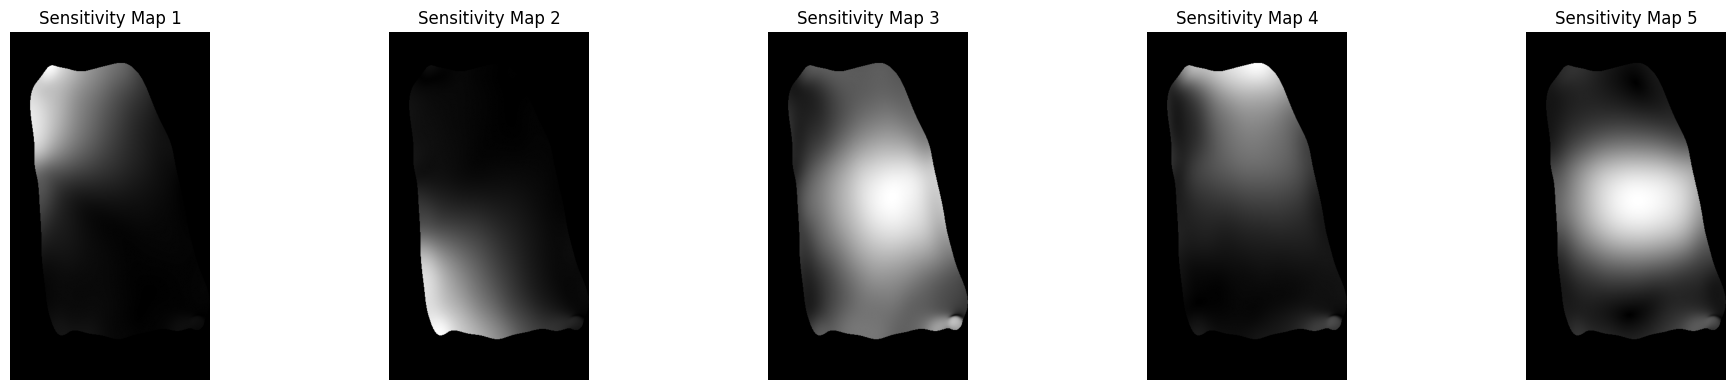

In [5]:
# Visualize first 5 ESPIRiT sensitivity maps (magnitude)
import math
import matplotlib.pyplot as plt
import torch

# Expecting this key from your dataloader when methods_flags=[1,1]
sens = batch['sensitivity_maps']

# Handle possible shapes after DataLoader collation:
# (B, C, H, W, 2) or (C, H, W, 2) or complex dtype variants
if sens.ndim == 5:
    # Take first sample in batch -> (C, H, W, 2) or (C, H, W) complex
    sens = sens[0]
elif sens.ndim != 4 and sens.ndim != 3:
    raise ValueError(f"Unexpected sensitivity map shape: {tuple(sens.shape)}")

# Convert to magnitude maps per coil
if torch.is_complex(sens):
    sens_mag = torch.abs(sens)  # (C, H, W)
elif sens.ndim == 4 and sens.shape[-1] == 2:
    # real/imag in last dim
    sens_mag = torch.sqrt(sens[..., 0] ** 2 + sens[..., 1] ** 2)  # (C, H, W)
elif sens.ndim == 3:
    # already magnitude or real-valued
    sens_mag = torch.abs(sens)
else:
    raise ValueError(f"Cannot interpret sensitivity map shape: {tuple(sens.shape)}")

n_maps = min(5, sens_mag.shape[0])
if n_maps == 0:
    raise ValueError("No sensitivity maps available to plot.")

fig, axes = plt.subplots(1, n_maps, figsize=(4 * n_maps, 4))
if n_maps == 1:
    axes = [axes]

for i in range(n_maps):
    img = sens_mag[i].detach().cpu().numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Sensitivity Map {i + 1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# normalization check

In [ ]:
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from fastmri.data import transforms as T
import os
import glob

# Replace with the actual folder where your .npy files are stored
# Add the missing forward slash at the end of the path
data_folder = "/home/biswamitra/health/knee_data/val/deconstructed_val/" 
your_list_of_paths = sorted(glob.glob(data_folder + "*.npy"))

print(f"Found {len(your_list_of_paths)} files.") # This should no longer be 0
# 1. Initialize your dataset and dataloader
# Ensure input_req[2] and output_req[2] are 1 to enable RSS
dataset = Custom_FMRI_DataLoader_nil(
    data_paths=your_list_of_paths, 
    input_req=[1, 1, 1, 1, 1],   # We only want masked RSS
    output_req=[1, 1, 1, 1]      # and full RSS
    ,methods_flags=[1,1]
)

import time

start_time = time.perf_counter()

loader = DataLoader(dataset, batch_size=10, shuffle=True)

# ==========================================
# DATA NORMALIZATION CHECK
# Run this right after creating your 'dataloader'
# ==========================================

print("Scanning a batch to check normalization...")

# Grab exactly one batch
batch = next(iter(loader))

masked_rss = batch['masked_rss_combined']
full_rss = batch['full_rss_combined']

# Calculate global min and max across the entire batch
masked_min, masked_max = masked_rss.min().item(), masked_rss.max().item()
full_min, full_max = full_rss.min().item(), full_rss.max().item()

print(f"\n--- Data Range Results ---")
print(f"Masked (Input)  -> Min: {masked_min:.4f} | Max: {masked_max:.4f}")
print(f"Full (Target)   -> Min: {full_min:.4f} | Max: {full_max:.4f}")

# Determine if it is normalized to [0, 1]
# (Using 1.0001 to account for tiny floating-point rounding errors)
if full_min >= 0.0 and full_max <= 1.0001:
    print("\n✅ Conclusion: Data is already normalized to [0, 1].")
    print("   Action: You can safely keep data_range=1.0 in your SSIM and PSNR functions.")
else:
    print("\n⚠️ Conclusion: Data is NOT normalized to [0, 1].")
    print(f"   Action: Your target maximum is {full_max:.4f}.")
    print("   Recommendation: Do NOT just change the data_range. Normalize the tensors before passing them to the U-Net.")

Found 7135 files.
Scanning a batch to check normalization...

--- Data Range Results ---
Masked (Input)  -> Min: 0.0000 | Max: 0.0005
Full (Target)   -> Min: 0.0000 | Max: 0.0006

✅ Conclusion: Data is already normalized to [0, 1].
   Action: You can safely keep data_range=1.0 in your SSIM and PSNR functions.


In [ ]:
# /home/mahesh/health_ai_ons/Biswa_nil/test_codes/test_2.5_activation_profilation/ZReLU/helper/layer_functions.py

SyntaxError: invalid decimal literal (2367936673.py, line 1)